### Step 1: The Environment SetupWe will create a standard 4x4 GridWorld. 
We need to "unwrap" the environment to see the math (the transition model $P$).

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import seaborn as sns

# Create the environment (Slippery for Stochastic, Non-slippery for Deterministic)
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)
env = env.unwrapped # This allows us to see the transition model P

# Constants
n_states = env.observation_space.n
n_actions = env.action_space.n
gamma = 0.99
threshold = 1e-8

### Step 2: Policy Evaluation (The "Imagine" Phase)
This function calculates how "valuable" every square is for a specific plan.

In [2]:
def policy_evaluation(policy, env, v_table, gamma, threshold):
    while True:
        delta = 0
        for s in range(n_states):
            old_v = v_table[s]
            new_v = 0
            # Look at what the policy says to do in this state
            action = policy[s]
            # Use the Transition Model P(s', r | s, a)
            for prob, next_state, reward, done in env.P[s][action]:
                new_v += prob * (reward + gamma * v_table[next_state])
            v_table[s] = new_v
            delta = max(delta, abs(old_v - new_v))
        if delta < threshold:
            break
    return v_table

### Step 3: Policy Iteration (The "Perfectionist" Algorithm)
This algorithm alternates between evaluating and improving. It is very thorough

In [3]:
def policy_iteration(env, gamma, threshold):
    # Start with a random policy (all 0s) and empty value table
    policy = np.zeros(n_states, dtype=int)
    v_table = np.zeros(n_states)
    
    for i in range(1000): # Limit to 1000 iterations
        # 1. Evaluate the current plan
        v_table = policy_evaluation(policy, env, v_table, gamma, threshold)
        
        # 2. Improve the plan (Make it greedy)
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            
            # Find the best action based on the new values
            action_values = []
            for a in range(n_actions):
                value = sum([prob * (reward + gamma * v_table[next_state]) 
                             for prob, next_state, reward, done in env.P[s][a]])
                action_values.append(value)
            
            policy[s] = np.argmax(action_values)
            if old_action != policy[s]:
                policy_stable = False
        
        if policy_stable:
            print(f"Policy Iteration converged at step {i}")
            break
    return v_table, policy

### Step 4: Value Iteration (The "Fast" Algorithm)
Value Iteration combines both steps into one sweep. It is much faster in real-world time.

In [4]:
def value_iteration(env, gamma, threshold):
    v_table = np.zeros(n_states)
    for i in range(1000):
        delta = 0
        for s in range(n_states):
            old_v = v_table[s]
            
            # Update value based on the BEST possible action (Max)
            action_values = []
            for a in range(n_actions):
                value = sum([prob * (reward + gamma * v_table[next_state]) 
                             for prob, next_state, reward, done in env.P[s][a]])
                action_values.append(value)
            
            v_table[s] = max(action_values)
            delta = max(delta, abs(old_v - v_table[s]))
        
        if delta < threshold:
            print(f"Value Iteration converged at step {i}")
            break
            
    # Extract the final policy
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        action_values = [sum([prob * (reward + gamma * v_table[next_state]) 
                         for prob, next_state, reward, done in env.P[s][a]]) 
                         for a in range(n_actions)]
        policy[s] = np.argmax(action_values)
        
    return v_table, policy

### Step 5: Visualizing the Results (Heatmap & Arrows)
This step addresses the "Section 2" feedback from your professor.

Policy Iteration converged at step 6


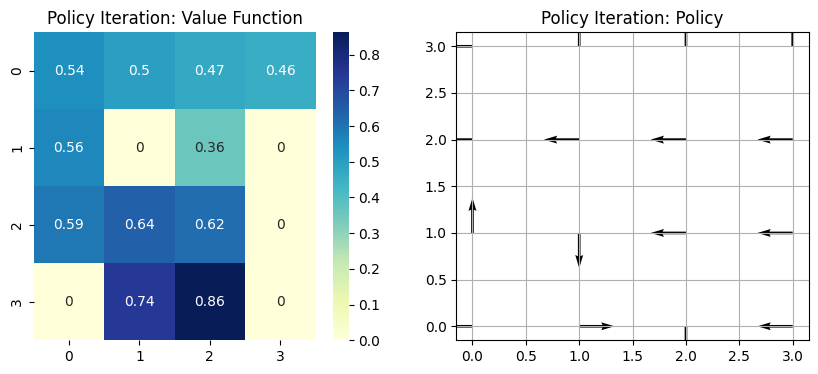

Value Iteration converged at step 323


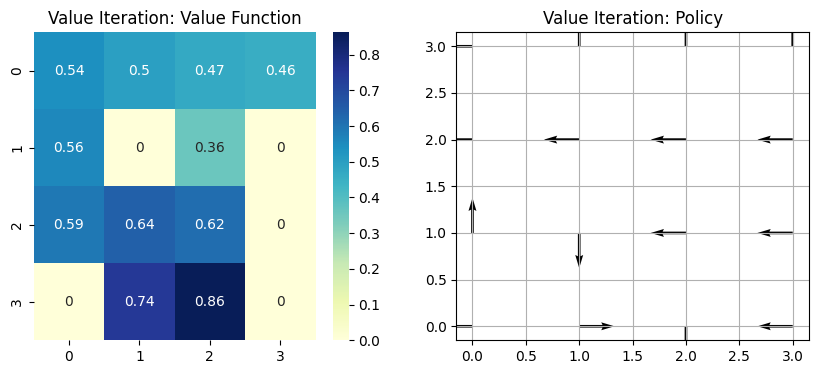

In [5]:
def plot_results(v_table, policy, title):
    # Create Heatmap
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(v_table.reshape(4,4), annot=True, cmap="YlGnBu")
    plt.title(f"{title}: Value Function")
    
    # Create Quiver Plot (Arrows)
    plt.subplot(1, 2, 2)
    # Map actions to arrows: 0:Left, 1:Down, 2:Right, 3:Up
    action_arrows = {0: (-1, 0), 1: (0, -1), 2: (1, 0), 3: (0, 1)}
    for s in range(n_states):
        y, x = divmod(s, 4)
        y = 3 - y # Flip Y to match grid coordinate
        dx, dy = action_arrows[policy[s]]
        plt.quiver(x, y, dx, dy, scale=10)
    plt.grid()
    plt.title(f"{title}: Policy")
    plt.show()

# Run and Plot
v_pi, p_pi = policy_iteration(env, gamma, threshold)
plot_results(v_pi, p_pi, "Policy Iteration")

v_vi, p_vi = value_iteration(env, gamma, threshold)
plot_results(v_vi, p_vi, "Value Iteration")